<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/v3_EDA_Balancing_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHSAT EDA and Balancing Notebook
Implements stratified summaries, class imbalance handling, focal loss utilities, and Bayesian class weighting preparation according to the methodology.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/Balanced%20Accident%20Descriptions.csv")
df = df.rename(columns={'Data':'date','Genre':'gender','Accident Level':'accident_level','Potential Accident Level':'potential_accident_level','Critical Risk':'critical_risk','Description':'description'})
severity_map={'I':1,'II':2,'III':3,'IV':4,'V':5}
df['severity']=df['accident_level'].map(severity_map)
df['potential_severity']=df['potential_accident_level'].map(severity_map)
df['near_miss_gap']=df['potential_severity']-df['severity']
df=df.dropna(subset=['severity'])
df['severity_label']=df['severity']-1
print(df[['severity','potential_severity','near_miss_gap']].head())
print(df[['severity','potential_severity','near_miss_gap']].tail())

   severity  potential_severity  near_miss_gap
0       1.0                 4.0            3.0
1       1.0                 4.0            3.0
2       1.0                 3.0            2.0
3       1.0                 1.0            0.0
4       4.0                 4.0            0.0
      severity  potential_severity  near_miss_gap
1592       2.0                 2.0            0.0
1593       2.0                 3.0            1.0
1594       2.0                 2.0            0.0
1595       2.0                 3.0            1.0
1596       2.0                 2.0            0.0


In [4]:
# Stratified summaries
print('Severity Distribution\t')
print(df['severity'].value_counts().sort_index())
print('\t')
print('Severity by Critical Risk\t')
print(pd.crosstab(df['critical_risk'],df['severity']).head())
print('\t')
print(pd.crosstab(df['critical_risk'],df['severity']).tail())
print('\t')
print('Severity proportions\t')
print(df['severity'].value_counts(normalize=True).sort_index())


Severity Distribution	
severity
1.0    316
2.0    300
3.0    331
4.0    330
5.0    320
Name: count, dtype: int64
	
Severity by Critical Risk	
severity                            1.0  2.0  3.0  4.0  5.0
critical_risk                                              
\nNot applicable                      0    0    0    1    0
Amputation, Crushing                  0    0    0    0   54
Asphyxiation, Drowning                0    0    0    0    8
Bees                                 10    0    0    0    0
Blocking and isolation of energies    3    0    0    0    0
	
severity                       1.0  2.0  3.0  4.0  5.0
critical_risk                                         
Traffic                          1    0    0    0    0
Transport                        0   36   48   39    0
Vehicles and Mobile Equipment    5    1    0    1    1
Venomous Animals                16    0    0    0    0
remains of choco                 2    2    0    2    1
	
Severity proportions	
severity
1.0    0.197871
2.

In [5]:
# Stratified train-test split
train_df,test_df=train_test_split(df,test_size=0.2,stratify=df['severity_label'],random_state=42)
print(train_df['severity_label'].value_counts(normalize=True).sort_index())
print(test_df['severity_label'].value_counts(normalize=True).sort_index())


severity_label
0.0    0.198121
1.0    0.187940
2.0    0.206735
3.0    0.206735
4.0    0.200470
Name: proportion, dtype: float64
severity_label
0.0    0.196875
1.0    0.187500
2.0    0.209375
3.0    0.206250
4.0    0.200000
Name: proportion, dtype: float64


In [6]:
# Class weights for imbalanced data
classes=np.unique(df['severity_label'])
weights=compute_class_weight(class_weight='balanced',classes=classes,y=df['severity_label'])
class_weights=dict(zip(classes,weights))
print(class_weights)


{np.float64(0.0): np.float64(1.0107594936708861), np.float64(1.0): np.float64(1.0646666666666667), np.float64(2.0): np.float64(0.9649546827794562), np.float64(3.0): np.float64(0.9678787878787879), np.float64(4.0): np.float64(0.998125)}


In [7]:
# Focal Loss for Transformer models
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
    def forward(self,inputs,targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
        pt=torch.exp(-ce)
        loss=((1-pt)**self.gamma)*ce
        return loss.mean()

alpha=torch.tensor(weights,dtype=torch.float32)
criterion=FocalLoss(alpha=alpha,gamma=2.0)
print('Focal loss ready for DistilBERT/BERT training.')


Focal loss ready for DistilBERT/BERT training.


In [8]:
# Bayesian class weighting preparation
# These weights can be incorporated into the likelihood term
# of Bayesian logistic or ordinal models.

bayesian_class_weights = {int(k):float(v) for k,v in class_weights.items()}
print(bayesian_class_weights)


{0: 1.0107594936708861, 1: 1.0646666666666667, 2: 0.9649546827794562, 3: 0.9678787878787879, 4: 0.998125}


          count  mean_near_miss_gap
severity                           
1.0         253            1.739130
2.0         240            0.600000
3.0         264            0.549242
4.0         264            0.318182
5.0         256            0.000000


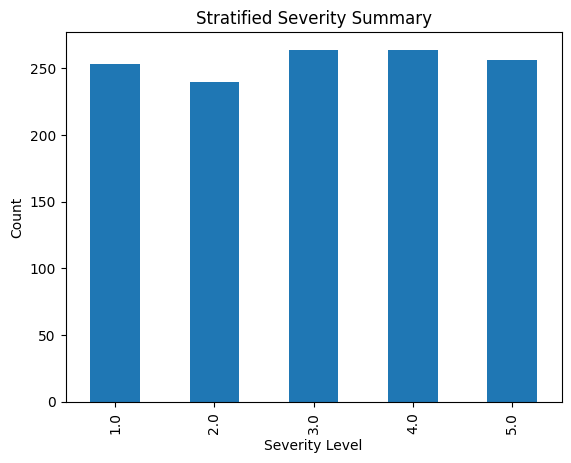

In [9]:
# Example ordinal severity summaries
summary=train_df.groupby('severity').agg(
    count=('severity','count'),
    mean_near_miss_gap=('near_miss_gap','mean')
)
print(summary)
summary['count'].plot(kind='bar')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.title('Stratified Severity Summary')
plt.show()
